# Integrated Test — Does B's Elaborative Rehearsal Improve QA Accuracy?

`03` established `chunked_sequential` as the uncompressed control this pipeline needs to beat. `07b` finished training B (stage 2) — this is that comparison.


In [111]:
import json
import os
import re
import sys
import threading
import time
from collections import deque
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

root = Path.cwd()
while not (root / "src").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

from src.notebook_setup import setup_project

setup_project()
API_KEY_SET = bool(os.environ.get("NVIDIA_NIM_API_KEY"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from tqdm.auto import tqdm
import torch
from safetensors.torch import load_file
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

from src.pipeline.embeddings import embed_texts, load_config as load_embed_config
from src.pipeline.rehearsal import rehearse_elaborative
from src.pipeline.types import Chunk

STAGE2_CHECKPOINT_RATIO0 = True  # set True to use the self_conditioned_ratio=0.0 ablation checkpoint (07b, 2026-08-07) instead of the main run (ratio=0.3) -- the ablation halved the collapse drop (+0.110 -> +0.050) against the teacher

# Base-model toggle (2026-08-10): use the flan-t5-base stage-2 checkpoint
# (07b) instead of t5-small. Only exists combined with ratio=0.0 -- no
# flan-t5-base ratio=0.3 run was ever trained, so this ignores
# STAGE2_CHECKPOINT_RATIO0 when True. Higher absolute retention at nearly
# every age than either t5-small config (early 0.395 / late 0.308 vs
# t5-small ratio0's 0.312 / 0.263), but a worse drop (+0.088 vs +0.050) --
# see 07b's Summary. Whether that translates into higher downstream QA
# accuracy here is exactly what re-running this notebook with it answers.
BASE_MODEL_FLANT5 = False

if BASE_MODEL_FLANT5:
    STAGE2_DIR = Path("experiments/rehearsal_elaborative_stage2_flant5base_ratio0")
elif STAGE2_CHECKPOINT_RATIO0:
    STAGE2_DIR = Path("experiments/rehearsal_elaborative_stage2_ratio0")
else:
    STAGE2_DIR = Path("experiments/rehearsal_elaborative_stage2")
STAGE2_READY = STAGE2_DIR.exists()
STAGE2_STATUS = "ready" if STAGE2_READY else "MISSING \u2014 run 07b first"
print(f"STAGE2_CHECKPOINT_RATIO0: {STAGE2_CHECKPOINT_RATIO0}")
print(f"BASE_MODEL_FLANT5: {BASE_MODEL_FLANT5}")
print(f"stage-2 checkpoint: {STAGE2_STATUS} ({STAGE2_DIR})")


def _ckpt_results_path(base_path: str) -> str:
    """Appends a checkpoint-identifying suffix to a results path so
    results from different checkpoints never land in the same file --
    same discipline as every other mechanism change in this notebook
    (delete-before-rerun bugs happened more than once this session from
    skipping this)."""
    if BASE_MODEL_FLANT5:
        suffix = "_flant5base"
    elif STAGE2_CHECKPOINT_RATIO0:
        suffix = "_ratio0chk"
    else:
        return base_path
    stem, dot, ext = base_path.rpartition(".")
    return f"{stem}{suffix}{dot}{ext}"

project root: /Users/lucyroh/Desktop/STUDY/Data Projects/rehearse-then-recall
.env loaded: success ✅
NVIDIA_NIM_API_KEY: set ✅
STAGE2_CHECKPOINT_RATIO0: True
BASE_MODEL_FLANT5: False
stage-2 checkpoint: ready (experiments/rehearsal_elaborative_stage2_ratio0)


## 1. Genres, corpora, questions — identical to `03`

Same files, loaded independently (kept byte-identical) so the eval set matches exactly.


In [112]:
GENRES = {
    "wiki": {
        "corpus_path": "data/processed/wiki_eval/wiki_eval_corpus.txt",
        "questions_path": "data/sample/wiki_eval_questions.csv",
        "format": "extractive",
    },
    "news": {
        "corpus_path": "data/processed/news_eval/news_eval_corpus.txt",
        "questions_path": "data/sample/news_eval_questions.csv",
        "format": "extractive",
    },
    "novel": {
        "corpus_path": "data/processed/narrativeqa_length_stress/novel_eval_corpus.txt",
        "questions_path": "data/sample/narrativeqa_novel_eval_questions.csv",
        "format": "extractive",
    },
    "caselaw": {
        "corpus_path": "data/processed/caselaw_eval/caselaw_eval_corpus.txt",
        "questions_path": "data/sample/caselaw_eval_questions.csv",
        "format": "multiple_choice",
    },
}

corpora: dict[str, str] = {}
questions: dict[str, pd.DataFrame] = {}

for genre, cfg in GENRES.items():
    with open(cfg["corpus_path"], encoding="utf-8") as f:
        corpora[genre] = f.read()
    qdf = pd.read_csv(cfg["questions_path"], encoding="utf-8-sig")
    questions[genre] = qdf
    print(f"{genre:10} format={cfg['format']:16} corpus={len(corpora[genre].split()):>6} words, questions={len(qdf):>4}")

wiki       format=extractive       corpus= 14934 words, questions= 100
news       format=extractive       corpus= 50443 words, questions= 200
novel      format=extractive       corpus= 59027 words, questions=  79
caselaw    format=multiple_choice  corpus= 54791 words, questions= 200


## Shared constants — used throughout, defined early on purpose

Defined early so comparison cells work regardless of run order.


In [ ]:
CONDITIONS_ORDER = [
    "closed_book",
    "full_context",
    "chunked_sequential",
    "chunked_sequential_rehearsal",
    "full_context_rehearsal_lookup",
    "full_context_rehearsal_lookup_retrieval",
    "full_context_rehearsal_lookup_adaptive",
]
CONDITION_COLORS = {
    "closed_book": "#2a78d6",
    "full_context": "#eb6834",
    "chunked_sequential": "#1baf7a",
    "chunked_sequential_rehearsal": "#a83279",
    "full_context_rehearsal_lookup": "#c9a227",
    "full_context_rehearsal_lookup_retrieval": "#6b4fa0",
    "full_context_rehearsal_lookup_adaptive": "#d6336c",
}
GENRE_ORDER = list(GENRES.keys())

baseline_df = pd.read_csv("results/qa_baseline_3conditions.csv", encoding="utf-8-sig")

## 2. Chunking — identical to `03`

Same `paginate_semantic` config, so chunk boundaries match `03`'s exactly.


In [114]:
chunks_by_genre: dict[str, list] = {}

if not API_KEY_SET:
    print("No NVIDIA_NIM_API_KEY \u2014 skipping chunk generation.")
else:
    from src.pipeline.chuncking import paginate_semantic, plain_text_to_paragraphs
    from src.pipeline.embeddings import embed_texts as _embed_texts_for_chunking, load_config as _load_chunk_embed_config

    chunk_cfg = yaml.safe_load(open("configs/chunking.yaml", encoding="utf-8"))
    chunk_embed_cfg = _load_chunk_embed_config("configs/importance_filter.yaml")

    for genre, text in corpora.items():
        paragraphs = plain_text_to_paragraphs(text)
        chunks_by_genre[genre] = paginate_semantic(
            paragraphs,
            min_words=chunk_cfg["min_words"],
            max_words=chunk_cfg["max_words"],
            granularity="paragraph",
            config=chunk_embed_cfg,
            embed_fn=_embed_texts_for_chunking,
        )
        print(f"{genre:10} chunks: {len(chunks_by_genre[genre])}")

wiki       chunks: 107
news       chunks: 390
novel      chunks: 498
caselaw    chunks: 400


## 3. Precompute B's rolling memory state, per genre

B is query-agnostic, so the rolling memory state is the same for every question in a genre — computed once, reused.


In [115]:
MAX_CHUNKS_EXPLORE = 4  # matches 03's budget exactly

memory_states_by_genre: dict[str, list[str]] = {}

if not (API_KEY_SET and STAGE2_READY):
    print("Skipping \u2014 need both an API key and the stage-2 checkpoint.")
else:
    embed_cfg = load_embed_config()
    stage2_tokenizer = AutoTokenizer.from_pretrained(STAGE2_DIR)
    # BUG (2026-08-09/10, see 07b): AutoModelForSeq2SeqLM.from_pretrained()
    # re-ties lm_head.weight to shared.weight on load, silently discarding
    # this checkpoint's actually-trained (and genuinely different)
    # lm_head.weight -- produces fluent-looking garbage generation with no
    # error/warning. Fix: load normally (encoder/decoder embed_tokens stay
    # correctly tied to shared.weight, which is structural to T5 and must
    # survive), then surgically replace just lm_head.weight with the value
    # read straight from the checkpoint's safetensors file.
    stage2_model = AutoModelForSeq2SeqLM.from_pretrained(STAGE2_DIR)
    _state = load_file(str(STAGE2_DIR / "model.safetensors"))
    if "lm_head.weight" in _state:
        # Only some checkpoints (e.g. flan-t5-base-derived ones) actually
        # have a separately-trained lm_head.weight distinct from
        # shared.weight -- t5-small checkpoints here never had that
        # anomaly, so this key is simply absent for them and there is
        # nothing to fix (staying tied is correct in that case).
        stage2_model.lm_head.weight = torch.nn.Parameter(
            _state["lm_head.weight"].to(dtype=stage2_model.lm_head.weight.dtype)
        )
        stage2_model.config.tie_word_embeddings = False
        assert stage2_model.lm_head.weight is not stage2_model.shared.weight, "lm_head got re-tied -- fix didn't take"
        print("lm_head fix applied (checkpoint has a separately-trained lm_head.weight)")
    else:
        print("lm_head.weight not present as a separate key -- checkpoint is genuinely tied, nothing to fix")

    for genre, chunk_list in chunks_by_genre.items():
        explore_chunks = chunk_list[:MAX_CHUNKS_EXPLORE]
        rehearsal_chunks = [Chunk(text=c.text, index=i) for i, c in enumerate(explore_chunks)]
        _, records = rehearse_elaborative(
            rehearsal_chunks, stage2_model, stage2_tokenizer, embed_cfg, embed_texts,
            record_memory_state=True,
        )
        memory_states_by_genre[genre] = [r.memory_state for r in records]
        lengths = [len(s.split()) for s in memory_states_by_genre[genre]]
        print(f"{genre:10} memory state lengths (words) by step: {lengths}")

lm_head.weight not present as a separate key -- checkpoint is genuinely tied, nothing to fix
wiki       memory state lengths (words) by step: [53, 53, 106, 159]
news       memory state lengths (words) by step: [50, 100, 150, 200]
novel      memory state lengths (words) by step: [18, 36, 54, 72]
caselaw    memory state lengths (words) by step: [37, 74, 111, 148]


## 4. NIM chat API call

Same implementation as `03` (rate limiter, backoff, usage tracking), duplicated not imported.


In [116]:
QA_MODEL = "meta/llama-3.1-8b-instruct"
QA_API_KEY = os.environ.get("NVIDIA_NIM_API_KEY")
_CHAT_API_URL = "https://integrate.api.nvidia.com/v1/chat/completions"
_RETRYABLE_STATUS = {429, 500, 502, 503, 504}

_usage_local = threading.local()


def last_chat_usage() -> dict | None:
    return getattr(_usage_local, "value", None)


class RateLimiter:
    def __init__(self, max_per_minute: int):
        self.max_per_minute = max_per_minute
        self._lock = threading.Lock()
        self._timestamps: deque = deque()

    def acquire(self) -> None:
        while True:
            with self._lock:
                now = time.time()
                while self._timestamps and now - self._timestamps[0] > 60:
                    self._timestamps.popleft()
                if len(self._timestamps) < self.max_per_minute:
                    self._timestamps.append(now)
                    return
                sleep_for = 60 - (now - self._timestamps[0])
            time.sleep(max(sleep_for, 0.1))


_rate_limiter = RateLimiter(max_per_minute=30)


def call_chat(messages: list[dict], model: str, api_key: str, timeout: float = 120.0, max_retries: int = 3) -> str:
    last_error: Exception | None = None
    for attempt in range(max_retries + 1):
        _rate_limiter.acquire()
        try:
            response = requests.post(
                _CHAT_API_URL,
                headers={"Authorization": f"Bearer {api_key}", "Accept": "application/json"},
                json={"model": model, "messages": messages, "temperature": 0.0},
                timeout=timeout,
            )
        except (requests.exceptions.Timeout, requests.exceptions.ConnectionError) as e:
            last_error = e
            if attempt < max_retries:
                time.sleep(3.0 * (attempt + 1))
                continue
            raise RuntimeError(f"NIM chat API call failed (retries exhausted): {e}") from e

        if response.status_code == 200:
            payload = response.json()
            _usage_local.value = payload.get("usage")
            return payload["choices"][0]["message"]["content"]
        if response.status_code in _RETRYABLE_STATUS and attempt < max_retries:
            time.sleep(3.0 * (attempt + 1))
            continue
        raise RuntimeError(f"NIM chat API failed ({response.status_code}): {response.text}")

    raise RuntimeError(f"NIM chat API call failed (retries exhausted): {last_error}")

## 5. Scoring + message builders — identical to `03`

Same `is_correct`, same question-turn prompt.


In [117]:
import requests

_NO_TOOLS_SENTENCE = (
    "Do not use web search or any external tool \u2014 answer using only the information "
    "given to you (or your own prior knowledge)."
)
_OPEN_ANSWER_INSTRUCTION = "Answer with only the answer itself, as briefly as possible (a word or short phrase). No other explanation."
_MC_ANSWER_INSTRUCTION = "Answer with only the number (1-5) of the correct option. No other explanation."
_CONTINUE_SIGNAL = "CONTINUE"


def normalize_answer(text: str) -> str:
    text = re.sub(r"[\s\.,!?'\"()\[\]{}]", "", text)
    return text.lower()


def is_correct_extractive(prediction: str, reference: str) -> bool:
    norm_ref = normalize_answer(reference)
    if not norm_ref:
        return False
    return norm_ref in normalize_answer(prediction)


def parse_option_number(text: str) -> int | None:
    match = re.search(r"[1-5]", text)
    return int(match.group()) if match else None


def is_correct(genre: str, row: pd.Series, prediction: str | None) -> bool:
    if prediction is None:
        return False
    if GENRES[genre]["format"] == "multiple_choice":
        pred_idx = parse_option_number(prediction)
        return pred_idx is not None and (pred_idx - 1) == row["correct_option_index"]
    return is_correct_extractive(prediction, row["answer"])


def _question_turn(genre: str, row: pd.Series) -> dict:
    if GENRES[genre]["format"] == "multiple_choice":
        options_text = "\n".join(f"{i + 1}) {row[f'option_{i}']}" for i in range(5))
        content = f"{_MC_ANSWER_INSTRUCTION}\n\nQuestion: {row['question']}\n{options_text}"
    else:
        content = f"{_OPEN_ANSWER_INSTRUCTION}\n\nQuestion: {row['question']}"
    return {"role": "user", "content": content}

## 6. Condition 1 — `chunked_sequential_rehearsal` (B alone, same tiny budget as the raw baseline)

Same loop as `03`'s `chunked_sequential`; only change is showing B's compressed memory state instead of raw chunk text.


In [118]:
def run_chunked_sequential_rehearsal(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """Same shape as 03's run_chunked_sequential, except each step shows B's
    compressed rolling memory state instead of the raw chunk text."""
    fmt = GENRES[genre]["format"]
    answer_hint = "a number 1-5" if fmt == "multiple_choice" else "a short answer"
    states = memory_states_by_genre[genre]
    system = {
        "role": "system",
        "content": (
            f"{_NO_TOOLS_SENTENCE} You are an assistant that answers questions. You'll be shown a "
            f"running summary of the source text, updated one step at a time (up to {len(states)}). "
            f"After each step, if you're already confident, output {answer_hint}; if not yet confident "
            f"and want to see the next step, output only '{_CONTINUE_SIGNAL}'."
        ),
    }
    messages = [system, _question_turn(genre, row)]

    total_elapsed = 0.0
    total_tokens = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
    prediction = None
    steps_used = 0

    for i, state in enumerate(states):
        is_last = i == len(states) - 1
        instruction = (
            f"This is the last step you'll see \u2014 you must answer now ({answer_hint})."
            if is_last
            else f"If you can answer now, do so ({answer_hint}); otherwise output only '{_CONTINUE_SIGNAL}'."
        )
        messages.append(
            {"role": "user", "content": f"[step {i + 1}/{len(states)}]\n{state}\n\n{instruction}"}
        )

        t0 = time.time()
        reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
        total_elapsed += time.time() - t0
        steps_used = i + 1

        usage = last_chat_usage() or {}
        for key in total_tokens:
            total_tokens[key] += usage.get(key) or 0

        messages.append({"role": "assistant", "content": reply})

        candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
        looks_like_continue = fmt != "multiple_choice" and _CONTINUE_SIGNAL.lower() in reply.strip().lower()
        if fmt == "multiple_choice":
            if candidate is not None:
                prediction = str(candidate)
                break
        elif not looks_like_continue and candidate:
            prediction = candidate
            break

    return {
        "prediction": prediction,
        "api_calls": steps_used,
        "elapsed_seconds": round(total_elapsed, 1),
        "prompt_tokens": total_tokens["prompt_tokens"],
        "completion_tokens": total_tokens["completion_tokens"],
        "total_tokens": total_tokens["total_tokens"],
    }

## 10. Cost gate

579 questions x up to 4 calls each — comparable to `03`'s own run. Checkpoints to a separate file.


In [119]:
CONDITION = "chunked_sequential_rehearsal"
RESULTS_PATH = _ckpt_results_path("results/qa_stage2_rehearsal_condition.csv")
CONFIRM_SPEND = True  # <- flip to True to actually call the QA model (reset 2026-08-07 before testing the new checkpoint)

total_questions = sum(len(questions[g]) for g in GENRES)
print(f"questions: {total_questions}, up to {4 * total_questions} QA calls (early-stop usually well under this)")
print(f"CONFIRM_SPEND = {CONFIRM_SPEND}")

questions: 579, up to 2316 QA calls (early-stop usually well under this)
CONFIRM_SPEND = True


In [120]:
def _run_one_question(genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_chunked_sequential_rehearsal(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": CONDITION,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {RESULTS_PATH} ({len(existing_df)} rows)")
else:
    existing_df = pd.DataFrame()

done_genres = set()
if len(existing_df):
    for genre, group in existing_df.groupby("genre"):
        if len(group) >= len(questions[genre]):
            done_genres.add(genre)

if not CONFIRM_SPEND:
    print("skipped \u2014 CONFIRM_SPEND is False")
    rehearsal_df = existing_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    rehearsal_df = existing_df
else:
    MAX_WORKERS = 8
    results = existing_df.to_dict("records")
    for genre in GENRES:
        if genre in done_genres:
            print(f"skip (already done): {genre}")
            continue
        if genre not in memory_states_by_genre:
            print(f"skip (no precomputed memory state): {genre}")
            continue

        qdf = questions[genre]
        results = [r for r in results if r["genre"] != genre]
        print(f"running: {genre} ({len(qdf)} questions)")
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            futures = [executor.submit(_run_one_question, genre, row) for _, row in qdf.iterrows()]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(RESULTS_PATH, index=False)

    rehearsal_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(rehearsal_df)}")

running: wiki (100 questions)


wiki: 100%|██████████| 100/100 [13:06<00:00,  7.86s/it]


running: news (200 questions)


news: 100%|██████████| 200/200 [23:03<00:00,  6.92s/it]


running: novel (79 questions)


novel: 100%|██████████| 79/79 [10:50<00:00,  8.23s/it] 


running: caselaw (200 questions)


caselaw: 100%|██████████| 200/200 [28:36<00:00,  8.58s/it]  


total results: 579


## 8. Condition 2 — `full_context_rehearsal_lookup` (ReadAgent-P: full gist map + selective raw lookup)

Tests full-document gists with selective raw-text lookup, rather than condition 1's tiny fixed budget.


In [122]:
full_gists_by_genre: dict[str, list] = {}

# Gisting is the GPU-bound bottleneck here (~1,200 chunks across the 4
# eval corpora, one generate() call each) -- scripts/gisting_gpu.py runs
# this same loop on a rented GPU and saves the result. Load it back if
# present instead of recomputing locally (2026-08-10).
_PRECOMPUTED_GISTS_PATH = Path(_ckpt_results_path("results/full_gists_by_genre.json"))

if _PRECOMPUTED_GISTS_PATH.exists():
    _raw = json.load(open(_PRECOMPUTED_GISTS_PATH, encoding="utf-8"))
    full_gists_by_genre = {genre: [Chunk(**c) for c in chunk_dicts] for genre, chunk_dicts in _raw.items()}
    for genre, rehearsed in full_gists_by_genre.items():
        raw_words = sum(len(c.original_text.split()) for c in rehearsed)
        gist_words = sum(len(c.text.split()) for c in rehearsed)
        print(f"{genre:10} {len(rehearsed):4} chunks | raw {raw_words:6} words -> "
                f"gist {gist_words:6} words ({gist_words / raw_words:.1%}) [loaded from {_PRECOMPUTED_GISTS_PATH}]")
elif not (API_KEY_SET and STAGE2_READY):
    print("Skipping \u2014 need both an API key and the stage-2 checkpoint.")
else:
    for genre, chunk_list in chunks_by_genre.items():
        full_chunks = [Chunk(text=c.text, index=i) for i, c in enumerate(chunk_list)]
        rehearsed, _ = rehearse_elaborative(
            full_chunks, stage2_model, stage2_tokenizer, embed_cfg, embed_texts,
        )
        full_gists_by_genre[genre] = rehearsed
        raw_words = sum(len(c.original_text.split()) for c in rehearsed)
        gist_words = sum(len(c.text.split()) for c in rehearsed)
        print(f"{genre:10} {len(rehearsed):4} chunks | raw {raw_words:6} words -> "
                f"gist {gist_words:6} words ({gist_words / raw_words:.1%})")

wiki        107 chunks | raw  14936 words -> gist   5216 words (34.9%)
news        390 chunks | raw  50444 words -> gist  17466 words (34.6%)


Token indices sequence length is longer than the specified maximum sequence length for this model (642 > 512). Running this sequence through the model will result in indexing errors


novel       498 chunks | raw  59031 words -> gist  20374 words (34.5%)
caselaw     400 chunks | raw  54804 words -> gist  16019 words (29.2%)


## 9. The lookup condition itself

`_parse_lookup_chunks` looks for a literal `LOOKUP: <numbers>` signal token in the reply.


In [123]:
LOOKUP_WINDOW = 2  # +/- chunks shown around each pointed-to chunk
MAX_LOOKUP_CHUNKS = 20  # set from §12's sweep (2026-08-06): w=2,c=20 had the best accuracy (0.350) and combined score of the grid -- not monotonic in cap, so this is a real optimum in the tested range, not just "as high as tested"


def _format_gist_list(rehearsed_chunks) -> str:
    return "\n".join(f"[chunk {c.index}] {c.text}" for c in rehearsed_chunks)


def _parse_lookup_chunks(reply: str, max_index: int) -> list[int] | None:
    """Looks for 'LOOKUP: 4, 24' (any number of comma/space-separated chunk
    numbers). Returns None if the reply isn't asking for a lookup at all."""
    match = re.search(r"LOOKUP:?\s*([\d,\s]+)", reply, re.IGNORECASE)
    if not match:
        return None
    numbers = [int(n) for n in re.findall(r"\d+", match.group(1))]
    valid = [n for n in numbers if 0 <= n <= max_index]
    return valid or None


def _lookup_window_indices(targets: list[int], max_index: int) -> list[int]:
    """Union of +/- LOOKUP_WINDOW around each target, capped at
    MAX_LOOKUP_CHUNKS total. Targets are processed in the order the model
    gave them; once one target's window is included, a further target is
    only added if it fits under the cap without exceeding it -- a model
    naming many chunks doesn't get to blow the raw-text budget open."""
    selected: set[int] = set()
    for target in targets:
        window = set(range(max(0, target - LOOKUP_WINDOW), min(max_index, target + LOOKUP_WINDOW) + 1))
        if selected and len(selected | window) > MAX_LOOKUP_CHUNKS:
            break
        selected |= window
    return sorted(selected)[:MAX_LOOKUP_CHUNKS]


def run_full_context_rehearsal_lookup(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """ReadAgent-P: show every chunk's gist at once (numbered); if that's not
    enough, the model can point at one or more chunk numbers and gets their
    raw text (+/- LOOKUP_WINDOW neighbours, capped at MAX_LOOKUP_CHUNKS) for
    a second, final call.

    The second call is a FRESH short prompt (system + raw text + question),
    not a continuation of the first call's message history. Reusing the full
    history would resend the entire gist block (tens of thousands of tokens
    for caselaw/novel) a second time, burying the one useful addition -- the
    raw text -- behind a duplicate wall of noise. A pilot run confirmed this
    was actively making answers worse: accuracy on lookup-triggered questions
    was far below both full_context and the no-lookup direct-answer path,
    while prompt tokens roughly doubled on every trigger, matching the size
    of the gist block being resent rather than the (much smaller) raw
    addition. Dropping the resend fixes the root cause; MAX_LOOKUP_CHUNKS is
    a separate safety net against a model naming many chunks at once.
    """
    fmt = GENRES[genre]["format"]
    answer_hint = "a number 1-5" if fmt == "multiple_choice" else "a short answer"
    rehearsed_chunks = full_gists_by_genre[genre]
    max_index = len(rehearsed_chunks) - 1

    system = {
        "role": "system",
        "content": (
            f"{_NO_TOOLS_SENTENCE} You are an assistant that answers questions. You will be shown a "
            f"gist of every chunk of the source text, each labelled with its chunk number. If you can "
            f"answer confidently from the gists, output {answer_hint}. If not, output "
            f"'LOOKUP: <chunk numbers>' naming one or more chunk numbers most likely to contain the "
            f"answer, and you will be shown their original text."
        ),
    }
    gist_block = {"role": "user", "content": _format_gist_list(rehearsed_chunks)}
    messages = [system, gist_block, _question_turn(genre, row)]

    total_elapsed = 0.0
    total_tokens = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
    api_calls = 0
    lookup_used = False

    t0 = time.time()
    reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
    total_elapsed += time.time() - t0
    api_calls += 1
    usage = last_chat_usage() or {}
    for key in total_tokens:
        total_tokens[key] += usage.get(key) or 0

    lookup_targets = _parse_lookup_chunks(reply, max_index)

    if lookup_targets is None:
        candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
        prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else (candidate or None)
    else:
        lookup_used = True
        window_indices = _lookup_window_indices(lookup_targets, max_index)
        raw_block = "\n\n".join(f"[chunk {i}]\n{rehearsed_chunks[i].original_text}" for i in window_indices)

        followup_system = {
            "role": "system",
            "content": f"{_NO_TOOLS_SENTENCE} Answer the question using only the original passage text below.",
        }
        followup_messages = [
            followup_system,
            {"role": "user", "content": f"Original passage text:\n\n{raw_block}"},
            _question_turn(genre, row),
        ]

        t0 = time.time()
        reply2 = call_chat(followup_messages, model=model, api_key=api_key, timeout=120.0)
        total_elapsed += time.time() - t0
        api_calls += 1
        usage = last_chat_usage() or {}
        for key in total_tokens:
            total_tokens[key] += usage.get(key) or 0

        candidate = parse_option_number(reply2) if fmt == "multiple_choice" else reply2.strip()
        prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else candidate

    return {
        "prediction": prediction,
        "api_calls": api_calls,
        "lookup_used": lookup_used,
        "elapsed_seconds": round(total_elapsed, 1),
        "prompt_tokens": total_tokens["prompt_tokens"],
        "completion_tokens": total_tokens["completion_tokens"],
        "total_tokens": total_tokens["total_tokens"],
    }

## 7. Cost gate

Gist block scales with chunk count (caselaw ~400, wiki ~61) — test on a small slice first.


In [124]:
LOOKUP_CONDITION = "full_context_rehearsal_lookup"
LOOKUP_RESULTS_PATH = _ckpt_results_path("results/qa_stage2_rehearsal_lookup_condition.csv")
LOOKUP_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model (reset 2026-08-07 before testing the new checkpoint)
LOOKUP_PILOT_LIMIT = 20  # <- test at most this many NEW questions per genre; None = all

total_questions = sum(len(questions[g]) for g in GENRES)
print(f"questions: {total_questions}, up to {2 * total_questions} QA calls (1-2 per question)")
print("Gist-block size scales with chunk count \u2014 check the word counts printed in \u00a79 "
      "before running caselaw/novel at full scale.")
print(f"LOOKUP_CONFIRM_SPEND = {LOOKUP_CONFIRM_SPEND}   LOOKUP_PILOT_LIMIT = {LOOKUP_PILOT_LIMIT}")

questions: 579, up to 1158 QA calls (1-2 per question)
Gist-block size scales with chunk count — check the word counts printed in §9 before running caselaw/novel at full scale.
LOOKUP_CONFIRM_SPEND = True   LOOKUP_PILOT_LIMIT = 20


## Run the quiz (this is the cell that actually calls the QA model and scores it)

The real loop: asks every question, applies lookup, scores, checkpoints.


In [125]:
def _run_one_lookup_question(genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_full_context_rehearsal_lookup(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{genre}] question {row["question_id"]} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": LOOKUP_CONDITION,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(LOOKUP_RESULTS_PATH):
    existing_lookup_df = pd.read_csv(LOOKUP_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {LOOKUP_RESULTS_PATH} ({len(existing_lookup_df)} rows)")
else:
    existing_lookup_df = pd.DataFrame()

if not LOOKUP_CONFIRM_SPEND:
    print("skipped \u2014 LOOKUP_CONFIRM_SPEND is False")
    lookup_df = existing_lookup_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    lookup_df = existing_lookup_df
else:
    MAX_WORKERS_LOOKUP = 4  # lower than the other loops -- each question can be 2 large calls
    results = existing_lookup_df.to_dict("records")
    done_keys = {(r["genre"], str(r["question_id"])) for r in results}

    for genre in GENRES:
        if genre not in full_gists_by_genre:
            print(f"skip (no precomputed gists): {genre}")
            continue
        qdf = questions[genre]
        todo_rows = [row for _, row in qdf.iterrows() if (genre, str(row["question_id"])) not in done_keys]
        todo_rows = todo_rows[:LOOKUP_PILOT_LIMIT] if LOOKUP_PILOT_LIMIT is not None else todo_rows
        if not todo_rows:
            print(f"skip (already done): {genre}")
            continue

        print(f"running: {genre} ({len(todo_rows)} questions this batch)")
        with ThreadPoolExecutor(max_workers=MAX_WORKERS_LOOKUP) as executor:
            futures = [executor.submit(_run_one_lookup_question, genre, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(LOOKUP_RESULTS_PATH, index=False)

    lookup_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(lookup_df)}")

loaded checkpoint: results/qa_stage2_rehearsal_lookup_condition_ratio0chk.csv (160 rows)
running: wiki (20 questions this batch)


wiki: 100%|██████████| 20/20 [01:03<00:00,  3.15s/it]


running: news (20 questions this batch)


news: 100%|██████████| 20/20 [01:01<00:00,  3.09s/it]


running: novel (20 questions this batch)


novel: 100%|██████████| 20/20 [07:27<00:00, 22.38s/it] 


running: caselaw (20 questions this batch)


caselaw: 100%|██████████| 20/20 [01:00<00:00,  3.01s/it]


total results: 240


## 10b. Before / after — did the fix work?

Pre-fix pilot CSV was deleted (would've been skipped by the run loop); its numbers are hardcoded below as reference. This cell recomputes "after" fresh from `LOOKUP_RESULTS_PATH`.

**Before (pilot, n=20/genre, pre-fix)**:

| genre | not triggered | triggered | full_context |
|---|---|---|---|
| wiki | 0.600 (n=10) | 0.300 (n=10) | 0.810 |
| news | 0.500 (n=6) | 0.071 (n=14) | 0.395 |
| novel | 0.429 (n=14) | 0.000 (n=4) | 0.494 |
| caselaw | 0.231 (n=13) | 0.000 (n=7) | 0.360 |

Bug signature: accuracy collapsed when lookup fired; tokens roughly doubled (e.g. caselaw 24,719→51,578) matching the resent gist block's size.


In [126]:
BEFORE = {
    "wiki":    {"no_lookup": 0.600, "lookup": 0.300},
    "news":    {"no_lookup": 0.500, "lookup": 0.071},
    "novel":   {"no_lookup": 0.429, "lookup": 0.000},
    "caselaw": {"no_lookup": 0.231, "lookup": 0.000},
}

lookup_df = pd.read_csv(LOOKUP_RESULTS_PATH, encoding="utf-8-sig") if os.path.exists(LOOKUP_RESULTS_PATH) else pd.DataFrame()

if lookup_df.empty:
    print(f"No data yet in {LOOKUP_RESULTS_PATH} -- run \u00a710's loop first.")
else:
    after_acc = lookup_df.groupby(["genre", "lookup_used"])["correct"].agg(["mean", "count"])
    after_tokens = lookup_df.groupby(["genre", "lookup_used"])["prompt_tokens"].mean()

    header_row = f"{'genre':10} {'before(no-lookup)':>18} {'after(no-lookup)':>18} {'before(lookup)':>16} {'after(lookup)':>15}"
    print(header_row)
    for genre in GENRE_ORDER:
        before = BEFORE.get(genre, {})
        before_no = before.get("no_lookup", float("nan"))
        before_yes = before.get("lookup", float("nan"))
        after_no = after_acc.loc[(genre, False), "mean"] if (genre, False) in after_acc.index else float("nan")
        after_yes = after_acc.loc[(genre, True), "mean"] if (genre, True) in after_acc.index else float("nan")
        print(f"{genre:10} {before_no:>18.3f} {after_no:>18.3f} {before_yes:>16.3f} {after_yes:>15.3f}")

    print("\navg prompt tokens when lookup triggers (after fix, should be far below the ~2x-of-no-lookup pattern seen before):")
    print(after_tokens)

genre       before(no-lookup)   after(no-lookup)   before(lookup)   after(lookup)
wiki                    0.600              0.857            0.300           0.434
news                    0.500              0.083            0.071           0.056
novel                   0.429              0.148            0.000           0.030
caselaw                 0.231              0.280            0.000           0.286

avg prompt tokens when lookup triggers (after fix, should be far below the ~2x-of-no-lookup pattern seen before):
genre    lookup_used
caselaw  False          24725.080000
         True           26847.628571
news     False          24457.375000
         True           26369.083333
novel    False          30312.555556
         True           32663.363636
wiki     False           7176.285714
         True            8901.867925
Name: prompt_tokens, dtype: float64


## 10c. Condition 3 — `full_context_rehearsal_lookup_retrieval` (lookup + embedding-similarity targeting)

Adds embedding-similarity targeting on top of the base lookup condition.


In [127]:
from src.pipeline.embeddings import embed_with_retry, cosine_similarity

EMBED_RETRIEVAL_TOP_K = 3
RELATED_CHUNKS_TOP_M = 2  # per named chunk, how many content-related (not just adjacent) chunks to also pull in

chunk_embeddings_by_genre: dict[str, list] = {}

if not (API_KEY_SET and STAGE2_READY):
    print("Skipping \u2014 need both an API key and the stage-2 checkpoint.")
else:
    for genre, rehearsed_chunks in full_gists_by_genre.items():
        raw_texts = [c.original_text for c in rehearsed_chunks]
        embeddings = embed_with_retry(raw_texts, "passage", embed_cfg, embed_texts)
        if embeddings is None:
            print(f"{genre:10} embedding failed \u2014 retrieval augmentation unavailable for this genre")
            continue
        chunk_embeddings_by_genre[genre] = embeddings
        print(f"{genre:10} embedded {len(embeddings)} raw chunks for retrieval")

wiki       embedded 107 raw chunks for retrieval
news       embedded 390 raw chunks for retrieval
novel      embedded 498 raw chunks for retrieval
caselaw    embedded 400 raw chunks for retrieval


### The retrieval-augmented lookup function

Same shape as the base lookup function; only difference is what feeds `_lookup_window_indices` (embedding top-K added).


In [128]:
def _embedding_top_k(genre: str, question: str, k: int) -> list[int]:
    if genre not in chunk_embeddings_by_genre:
        return []
    query_embedding = embed_with_retry([question], "query", embed_cfg, embed_texts)
    if query_embedding is None:
        return []
    scored = [(i, cosine_similarity(query_embedding[0], emb)) for i, emb in enumerate(chunk_embeddings_by_genre[genre])]
    scored.sort(key=lambda x: x[1], reverse=True)
    return [i for i, _ in scored[:k]]


def _related_chunks(genre: str, chunk_index: int, m: int) -> list[int]:
    """Chunks related in *content* to chunk_index, wherever they sit in the
    document -- a cheap, embedding-only proxy for RST-LoRA's "relations
    between spans" idea (Liu & Demberg, NAACL 2024, arXiv:2405.00657):
    that paper types discourse relations (elaborates/contrasts/background)
    via a trained RST parser + LoRA adapter, which is a training-time method
    this project doesn't have the infra or time budget to add right now.
    This borrows the underlying instinct -- relatedness beats proximity --
    using cosine similarity between chunk embeddings we already computed,
    so it costs zero extra API calls."""
    if genre not in chunk_embeddings_by_genre:
        return []
    embeddings = chunk_embeddings_by_genre[genre]
    target_embedding = embeddings[chunk_index]
    scored = [
        (i, cosine_similarity(target_embedding, emb))
        for i, emb in enumerate(embeddings) if i != chunk_index
    ]
    scored.sort(key=lambda x: x[1], reverse=True)
    return [i for i, _ in scored[:m]]


def run_full_context_rehearsal_lookup_retrieval(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """Base lookup condition, plus: when the model asks for a lookup, the
    chunks shown are the union of (a) what it named, (b) the top
    EMBED_RETRIEVAL_TOP_K chunks by embedding similarity to the *question*,
    and (c) each named chunk's own top RELATED_CHUNKS_TOP_M most similar
    *other* chunks by embedding similarity (content-related, not just
    positionally adjacent) -- (b) recovers a right answer even when the
    model's own chunk-number guess is wrong; (c) recovers supporting detail
    scattered elsewhere in the document that a pure position window would
    miss."""
    fmt = GENRES[genre]["format"]
    answer_hint = "a number 1-5" if fmt == "multiple_choice" else "a short answer"
    rehearsed_chunks = full_gists_by_genre[genre]
    max_index = len(rehearsed_chunks) - 1

    system = {
        "role": "system",
        "content": (
            f"{_NO_TOOLS_SENTENCE} You are an assistant that answers questions. You will be shown a "
            f"gist of every chunk of the source text, each labelled with its chunk number. If you can "
            f"answer confidently from the gists, output {answer_hint}. If not, output "
            f"'LOOKUP: <chunk numbers>' naming one or more chunk numbers most likely to contain the "
            f"answer, and you will be shown their original text."
        ),
    }
    gist_block = {"role": "user", "content": _format_gist_list(rehearsed_chunks)}
    messages = [system, gist_block, _question_turn(genre, row)]

    total_elapsed = 0.0
    total_tokens = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
    api_calls = 0
    lookup_used = False

    t0 = time.time()
    reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
    total_elapsed += time.time() - t0
    api_calls += 1
    usage = last_chat_usage() or {}
    for key in total_tokens:
        total_tokens[key] += usage.get(key) or 0

    lookup_targets = _parse_lookup_chunks(reply, max_index)

    if lookup_targets is None:
        candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
        prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else (candidate or None)
    else:
        lookup_used = True
        retrieved = _embedding_top_k(genre, row["question"], EMBED_RETRIEVAL_TOP_K)
        related = [i for target in lookup_targets for i in _related_chunks(genre, target, RELATED_CHUNKS_TOP_M)]
        window_indices = _lookup_window_indices(lookup_targets + retrieved + related, max_index)
        raw_block = "\n\n".join(f"[chunk {i}]\n{rehearsed_chunks[i].original_text}" for i in window_indices)

        followup_system = {
            "role": "system",
            "content": f"{_NO_TOOLS_SENTENCE} Answer the question using only the original passage text below.",
        }
        followup_messages = [
            followup_system,
            {"role": "user", "content": f"Original passage text:\n\n{raw_block}"},
            _question_turn(genre, row),
        ]

        t0 = time.time()
        reply2 = call_chat(followup_messages, model=model, api_key=api_key, timeout=120.0)
        total_elapsed += time.time() - t0
        api_calls += 1
        usage = last_chat_usage() or {}
        for key in total_tokens:
            total_tokens[key] += usage.get(key) or 0

        candidate = parse_option_number(reply2) if fmt == "multiple_choice" else reply2.strip()
        prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else candidate

    return {
        "prediction": prediction,
        "api_calls": api_calls,
        "lookup_used": lookup_used,
        "elapsed_seconds": round(total_elapsed, 1),
        "prompt_tokens": total_tokens["prompt_tokens"],
        "completion_tokens": total_tokens["completion_tokens"],
        "total_tokens": total_tokens["total_tokens"],
    }

### Cost gate


In [129]:
RETRIEVAL_CONDITION = "full_context_rehearsal_lookup_retrieval"
RETRIEVAL_RESULTS_PATH = _ckpt_results_path("results/qa_stage2_rehearsal_lookup_retrieval_condition.csv")
RETRIEVAL_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model (reset 2026-08-07 before testing the new checkpoint)
RETRIEVAL_PILOT_LIMIT = 20  # <- test at most this many NEW questions per genre; None = all

total_questions = sum(len(questions[g]) for g in GENRES)
print(f"questions: {total_questions}, up to {2 * total_questions} QA calls (1-2 per question) "
      f"plus 1 query-embedding call per lookup-triggered question")
print(f"RETRIEVAL_CONFIRM_SPEND = {RETRIEVAL_CONFIRM_SPEND}   RETRIEVAL_PILOT_LIMIT = {RETRIEVAL_PILOT_LIMIT}")

questions: 579, up to 1158 QA calls (1-2 per question) plus 1 query-embedding call per lookup-triggered question
RETRIEVAL_CONFIRM_SPEND = True   RETRIEVAL_PILOT_LIMIT = 20


### Run the quiz


In [130]:
def _run_one_retrieval_question(genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_full_context_rehearsal_lookup_retrieval(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": RETRIEVAL_CONDITION,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(RETRIEVAL_RESULTS_PATH):
    existing_retrieval_df = pd.read_csv(RETRIEVAL_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {RETRIEVAL_RESULTS_PATH} ({len(existing_retrieval_df)} rows)")
else:
    existing_retrieval_df = pd.DataFrame()

if not RETRIEVAL_CONFIRM_SPEND:
    print("skipped \u2014 RETRIEVAL_CONFIRM_SPEND is False")
    retrieval_df = existing_retrieval_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    retrieval_df = existing_retrieval_df
else:
    MAX_WORKERS_RETRIEVAL = 4
    results = existing_retrieval_df.to_dict("records")
    done_keys = {(r["genre"], str(r["question_id"])) for r in results}

    for genre in GENRES:
        if genre not in full_gists_by_genre:
            print(f"skip (no precomputed gists): {genre}")
            continue
        qdf = questions[genre]
        todo_rows = [row for _, row in qdf.iterrows() if (genre, str(row["question_id"])) not in done_keys]
        todo_rows = todo_rows[:RETRIEVAL_PILOT_LIMIT] if RETRIEVAL_PILOT_LIMIT is not None else todo_rows
        if not todo_rows:
            print(f"skip (already done): {genre}")
            continue

        print(f"running: {genre} ({len(todo_rows)} questions this batch)")
        with ThreadPoolExecutor(max_workers=MAX_WORKERS_RETRIEVAL) as executor:
            futures = [executor.submit(_run_one_retrieval_question, genre, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(RETRIEVAL_RESULTS_PATH, index=False)

    retrieval_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(retrieval_df)}")

loaded checkpoint: results/qa_stage2_rehearsal_lookup_retrieval_condition_ratio0chk.csv (160 rows)
running: wiki (20 questions this batch)


wiki: 100%|██████████| 20/20 [01:10<00:00,  3.55s/it]


running: news (20 questions this batch)


news: 100%|██████████| 20/20 [01:51<00:00,  5.59s/it]


running: novel (20 questions this batch)


novel: 100%|██████████| 20/20 [03:53<00:00, 11.68s/it]


running: caselaw (20 questions this batch)


caselaw: 100%|██████████| 20/20 [00:47<00:00,  2.35s/it]


total results: 240


### Compare against the base lookup condition and `full_context`


In [131]:
base_lookup_df = pd.read_csv(LOOKUP_RESULTS_PATH, encoding="utf-8-sig") if os.path.exists(LOOKUP_RESULTS_PATH) else pd.DataFrame()
retrieval_df = pd.read_csv(RETRIEVAL_RESULTS_PATH, encoding="utf-8-sig") if os.path.exists(RETRIEVAL_RESULTS_PATH) else pd.DataFrame()
full_context_acc = baseline_df[baseline_df["condition"] == "full_context"].groupby("genre")["correct"].mean()
base_lookup_acc = base_lookup_df.groupby("genre")["correct"].mean() if not base_lookup_df.empty else pd.Series(dtype=float)
retrieval_acc = retrieval_df.groupby("genre")["correct"].mean() if not retrieval_df.empty else pd.Series(dtype=float)

print(f"{'genre':10} {'full_context':>14} {'lookup':>10} {'lookup+retrieval':>18}")
for g in GENRE_ORDER:
    fc = full_context_acc.get(g, float("nan"))
    bl = base_lookup_acc.get(g, float("nan"))
    rt = retrieval_acc.get(g, float("nan"))
    print(f"{g:10} {fc:>14.3f} {bl:>10.3f} {rt:>18.3f}")

genre        full_context     lookup   lookup+retrieval
wiki                0.810      0.483              0.733
news                0.395      0.067              0.183
novel               0.494      0.083              0.267
caselaw             0.360      0.283              0.283


## 12. Tuning `LOOKUP_WINDOW` / `MAX_LOOKUP_CHUNKS` — grid sweep

Both were first-guess values, never tuned. Grid over accuracy/token trade-off.


In [132]:
SWEEP_WINDOW_GRID = [2]  # window mostly matters for near-miss forgiveness; cap is the cost axis that matters here
SWEEP_CAP_GRID = [5, 10, 20, 40]  # 40 chunks * ~200 words = ~8000 words, still well under full_context's cost everywhere
SWEEP_PILOT_LIMIT = 10  # questions per genre per (window, cap) combo
SWEEP_COST_LAMBDA = 0.05  # weight on token cost in the combined score below
SWEEP_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model
SWEEP_RESULTS_PATH = "results/qa_stage2_lookup_sweep.csv"

sweep_combos = [(w, c) for w in SWEEP_WINDOW_GRID for c in SWEEP_CAP_GRID if c >= 2 * w + 1]
skipped_combos = [(w, c) for w in SWEEP_WINDOW_GRID for c in SWEEP_CAP_GRID if c < 2 * w + 1]
questions_per_combo = sum(min(len(questions[g]), SWEEP_PILOT_LIMIT) for g in GENRES)
print(f"{len(sweep_combos)} combos ({skipped_combos} skipped as cap < window span) "
      f"x {questions_per_combo} questions/combo x up to 2 calls "
      f"= up to {len(sweep_combos) * questions_per_combo * 2} calls")
print(f"SWEEP_CONFIRM_SPEND = {SWEEP_CONFIRM_SPEND}")

4 combos ([] skipped as cap < window span) x 40 questions/combo x up to 2 calls = up to 320 calls
SWEEP_CONFIRM_SPEND = True


In [133]:
def _run_sweep_combo(window: int, cap: int, done_keys: set) -> list[dict]:
    global LOOKUP_WINDOW, MAX_LOOKUP_CHUNKS
    LOOKUP_WINDOW, MAX_LOOKUP_CHUNKS = window, cap

    def _one(genre, row):
        try:
            outcome = run_full_context_rehearsal_lookup(genre, row, QA_MODEL, QA_API_KEY)
        except Exception as e:
            outcome = {
                "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
                "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
            }
            tqdm.write(f"  [w={window} c={cap} {genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
        return {
            "window": window, "cap": cap, "genre": genre, "question_id": row["question_id"],
            "correct": is_correct(genre, row, outcome["prediction"]),
            **outcome,
        }

    todo = [
        (genre, row) for genre in GENRES
        for _, row in questions[genre].iloc[:SWEEP_PILOT_LIMIT].iterrows()
        if (window, cap, genre, str(row["question_id"])) not in done_keys
    ]
    if not todo:
        return []

    rows = []
    with ThreadPoolExecutor(max_workers=4) as executor:
        futures = [executor.submit(_one, genre, row) for genre, row in todo]
        for future in tqdm(as_completed(futures), total=len(futures), desc=f"w={window} c={cap}"):
            rows.append(future.result())
    return rows


if os.path.exists(SWEEP_RESULTS_PATH):
    existing_sweep_df = pd.read_csv(SWEEP_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {SWEEP_RESULTS_PATH} ({len(existing_sweep_df)} rows)")
else:
    existing_sweep_df = pd.DataFrame()

if not SWEEP_CONFIRM_SPEND:
    print("skipped \u2014 SWEEP_CONFIRM_SPEND is False")
    sweep_df = existing_sweep_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    sweep_df = existing_sweep_df
else:
    _orig_window, _orig_cap = LOOKUP_WINDOW, MAX_LOOKUP_CHUNKS
    results = existing_sweep_df.to_dict("records")
    done_keys = {(r["window"], r["cap"], r["genre"], str(r["question_id"])) for r in results}

    for window, cap in sweep_combos:
        new_rows = _run_sweep_combo(window, cap, done_keys)
        if new_rows:
            results.extend(new_rows)
            pd.DataFrame(results).to_csv(SWEEP_RESULTS_PATH, index=False)

    LOOKUP_WINDOW, MAX_LOOKUP_CHUNKS = _orig_window, _orig_cap  # restore the notebook's real settings
    sweep_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(sweep_df)}  (LOOKUP_WINDOW/MAX_LOOKUP_CHUNKS restored to {_orig_window}/{_orig_cap})")

loaded checkpoint: results/qa_stage2_lookup_sweep.csv (160 rows)

total results: 160  (LOOKUP_WINDOW/MAX_LOOKUP_CHUNKS restored to 2/20)


### Sweep results

`accuracy - SWEEP_COST_LAMBDA * (avg_tokens / 10_000)` combines both axes
into one ranking; the scatter plot underneath shows the raw trade-off so
that ranking's arbitrariness stays visible rather than hidden.


 window  cap  accuracy   avg_tokens lookup_rate  n    score
      2   20     0.350 22750.600000       0.475 40 0.236247
      2   40     0.325 23059.200000         0.5 40 0.209704
      2    5     0.300 22136.717949    0.487179 40 0.189316
      2   10     0.275 22537.725000         0.5 40 0.162311


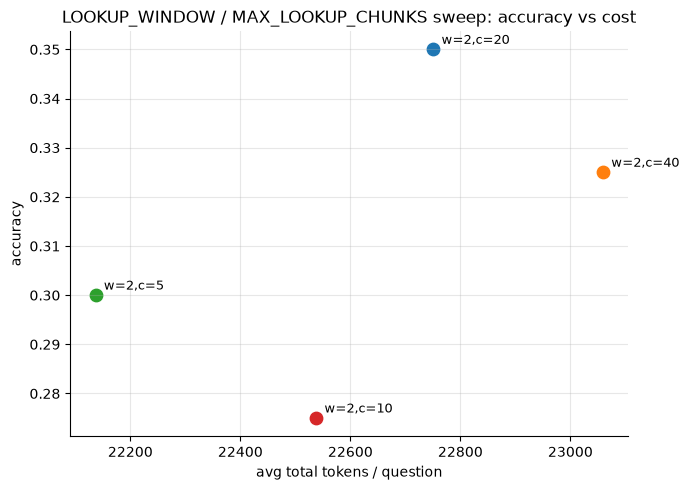

In [134]:
sweep_df = pd.read_csv(SWEEP_RESULTS_PATH, encoding="utf-8-sig") if os.path.exists(SWEEP_RESULTS_PATH) else pd.DataFrame()

if sweep_df.empty:
    print(f"No data yet in {SWEEP_RESULTS_PATH} -- set SWEEP_CONFIRM_SPEND = True above and run the sweep first.")
else:
    summary = sweep_df.groupby(["window", "cap"]).agg(
        accuracy=("correct", "mean"),
        avg_tokens=("total_tokens", "mean"),
        lookup_rate=("lookup_used", "mean"),
        n=("correct", "count"),
    ).reset_index()
    summary["score"] = summary["accuracy"] - SWEEP_COST_LAMBDA * (summary["avg_tokens"] / 10_000)
    summary = summary.sort_values("score", ascending=False)
    print(summary.to_string(index=False))

    fig, ax = plt.subplots(figsize=(7, 5))
    for _, r in summary.iterrows():
        ax.scatter(r["avg_tokens"], r["accuracy"], s=80)
        ax.annotate(f"w={r['window']},c={r['cap']}", (r["avg_tokens"], r["accuracy"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=9)
    ax.set_xlabel("avg total tokens / question")
    ax.set_ylabel("accuracy")
    ax.set_title("LOOKUP_WINDOW / MAX_LOOKUP_CHUNKS sweep: accuracy vs cost")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 13. Condition 4 — `full_context_rehearsal_lookup_adaptive` (adaptive-k lookup, generalizable, no per-genre tuning)

Replaces the retired per-genre cap with one mechanism: keep chunks within a relative margin of the top similarity score.


In [135]:
ADAPTIVE_RELATIVE_THRESHOLD = 0.85  # keep chunks scoring within this fraction of the top similarity score
ADAPTIVE_TARGET_WINDOW = 1  # small fixed window around the model's own named chunk(s), always included
ADAPTIVE_SAFETY_CAP = 40  # hard ceiling regardless of how many chunks pass the threshold -- a safety bound, not a tuned value


def _adaptive_chunk_selection(scored: list[tuple[int, float]], relative_threshold: float, safety_cap: int) -> list[int]:
    """Adaptive-k (arXiv:2506.08479): how many chunks are 'good enough' is
    decided by the shape of this question's own similarity-score
    distribution, not a fixed count or a per-genre table -- generalizes to
    any new document/domain without retuning."""
    if not scored:
        return []
    ranked = sorted(scored, key=lambda x: x[1], reverse=True)
    top_score = ranked[0][1]
    if top_score <= 0:
        return [ranked[0][0]]
    cutoff = top_score * relative_threshold
    selected = [i for i, score in ranked if score >= cutoff]
    return selected[:safety_cap]


def run_full_context_rehearsal_lookup_adaptive(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """Same first call as the other lookup conditions. When lookup triggers,
    the raw chunks shown are chosen adaptively -- see \u00a714's header --
    instead of by any fixed count or genre-keyed table."""
    fmt = GENRES[genre]["format"]
    answer_hint = "a number 1-5" if fmt == "multiple_choice" else "a short answer"
    rehearsed_chunks = full_gists_by_genre[genre]
    max_index = len(rehearsed_chunks) - 1

    system = {
        "role": "system",
        "content": (
            f"{_NO_TOOLS_SENTENCE} You are an assistant that answers questions. You will be shown a "
            f"gist of every chunk of the source text, each labelled with its chunk number. If you can "
            f"answer confidently from the gists, output {answer_hint}. If not, output "
            f"'LOOKUP: <chunk numbers>' naming one or more chunk numbers most likely to contain the "
            f"answer, and you will be shown their original text."
        ),
    }
    gist_block = {"role": "user", "content": _format_gist_list(rehearsed_chunks)}
    messages = [system, gist_block, _question_turn(genre, row)]

    total_elapsed = 0.0
    total_tokens = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
    api_calls = 0
    lookup_used = False

    t0 = time.time()
    reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
    total_elapsed += time.time() - t0
    api_calls += 1
    usage = last_chat_usage() or {}
    for key in total_tokens:
        total_tokens[key] += usage.get(key) or 0

    lookup_targets = _parse_lookup_chunks(reply, max_index)

    if lookup_targets is None:
        candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
        prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else (candidate or None)
    else:
        lookup_used = True

        query_embedding = embed_with_retry([row["question"]], "query", embed_cfg, embed_texts)
        if query_embedding is not None and genre in chunk_embeddings_by_genre:
            scored = [(i, cosine_similarity(query_embedding[0], emb)) for i, emb in enumerate(chunk_embeddings_by_genre[genre])]
            adaptive_selected = _adaptive_chunk_selection(scored, ADAPTIVE_RELATIVE_THRESHOLD, ADAPTIVE_SAFETY_CAP)
        else:
            adaptive_selected = []

        target_window: set[int] = set()
        for target in lookup_targets:
            target_window |= set(range(max(0, target - ADAPTIVE_TARGET_WINDOW), min(max_index, target + ADAPTIVE_TARGET_WINDOW) + 1))

        window_indices = sorted(set(adaptive_selected) | target_window)[:ADAPTIVE_SAFETY_CAP]
        raw_block = "\n\n".join(f"[chunk {i}]\n{rehearsed_chunks[i].original_text}" for i in window_indices)

        followup_system = {
            "role": "system",
            "content": f"{_NO_TOOLS_SENTENCE} Answer the question using only the original passage text below.",
        }
        followup_messages = [
            followup_system,
            {"role": "user", "content": f"Original passage text:\n\n{raw_block}"},
            _question_turn(genre, row),
        ]

        t0 = time.time()
        reply2 = call_chat(followup_messages, model=model, api_key=api_key, timeout=120.0)
        total_elapsed += time.time() - t0
        api_calls += 1
        usage = last_chat_usage() or {}
        for key in total_tokens:
            total_tokens[key] += usage.get(key) or 0

        candidate = parse_option_number(reply2) if fmt == "multiple_choice" else reply2.strip()
        prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else candidate

    return {
        "prediction": prediction,
        "api_calls": api_calls,
        "lookup_used": lookup_used,
        "elapsed_seconds": round(total_elapsed, 1),
        "prompt_tokens": total_tokens["prompt_tokens"],
        "completion_tokens": total_tokens["completion_tokens"],
        "total_tokens": total_tokens["total_tokens"],
    }


### Cost gate


In [136]:
ADAPTIVE_CONDITION = "full_context_rehearsal_lookup_adaptive"
ADAPTIVE_RESULTS_PATH = _ckpt_results_path("results/qa_stage2_rehearsal_lookup_adaptive_condition.csv")
ADAPTIVE_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model (reset 2026-08-07 before testing the new checkpoint)
ADAPTIVE_PILOT_LIMIT = 20  # <- test at most this many NEW questions per genre; None = all

total_questions = sum(len(questions[g]) for g in GENRES)
print(f"questions: {total_questions}, up to {2 * total_questions} QA calls (1-2 per question) "
      f"plus 1 query-embedding call per lookup-triggered question")
print(f"ADAPTIVE_RELATIVE_THRESHOLD = {ADAPTIVE_RELATIVE_THRESHOLD}   ADAPTIVE_SAFETY_CAP = {ADAPTIVE_SAFETY_CAP}")
print(f"ADAPTIVE_CONFIRM_SPEND = {ADAPTIVE_CONFIRM_SPEND}   ADAPTIVE_PILOT_LIMIT = {ADAPTIVE_PILOT_LIMIT}")


questions: 579, up to 1158 QA calls (1-2 per question) plus 1 query-embedding call per lookup-triggered question
ADAPTIVE_RELATIVE_THRESHOLD = 0.85   ADAPTIVE_SAFETY_CAP = 40
ADAPTIVE_CONFIRM_SPEND = True   ADAPTIVE_PILOT_LIMIT = 20


### Run the quiz


In [137]:
def _run_one_adaptive_question(genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_full_context_rehearsal_lookup_adaptive(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": ADAPTIVE_CONDITION,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(ADAPTIVE_RESULTS_PATH):
    existing_adaptive_df = pd.read_csv(ADAPTIVE_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {ADAPTIVE_RESULTS_PATH} ({len(existing_adaptive_df)} rows)")
else:
    existing_adaptive_df = pd.DataFrame()

if not ADAPTIVE_CONFIRM_SPEND:
    print("skipped \u2014 ADAPTIVE_CONFIRM_SPEND is False")
    adaptive_df = existing_adaptive_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    adaptive_df = existing_adaptive_df
else:
    MAX_WORKERS_ADAPTIVE = 4
    results = existing_adaptive_df.to_dict("records")
    done_keys = {(r["genre"], str(r["question_id"])) for r in results}

    for genre in GENRES:
        if genre not in full_gists_by_genre:
            print(f"skip (no precomputed gists): {genre}")
            continue
        qdf = questions[genre]
        todo_rows = [row for _, row in qdf.iterrows() if (genre, str(row["question_id"])) not in done_keys]
        todo_rows = todo_rows[:ADAPTIVE_PILOT_LIMIT] if ADAPTIVE_PILOT_LIMIT is not None else todo_rows
        if not todo_rows:
            print(f"skip (already done): {genre}")
            continue

        print(f"running: {genre} ({len(todo_rows)} questions this batch)")
        with ThreadPoolExecutor(max_workers=MAX_WORKERS_ADAPTIVE) as executor:
            futures = [executor.submit(_run_one_adaptive_question, genre, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(ADAPTIVE_RESULTS_PATH, index=False)

    adaptive_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(adaptive_df)}")


loaded checkpoint: results/qa_stage2_rehearsal_lookup_adaptive_condition_ratio0chk.csv (80 rows)
running: wiki (20 questions this batch)


wiki: 100%|██████████| 20/20 [02:44<00:00,  8.22s/it]


running: news (20 questions this batch)


news: 100%|██████████| 20/20 [00:32<00:00,  1.62s/it]


running: novel (20 questions this batch)


novel: 100%|██████████| 20/20 [01:27<00:00,  4.40s/it]


running: caselaw (20 questions this batch)


caselaw: 100%|██████████| 20/20 [01:01<00:00,  3.05s/it]


total results: 160


### Compare against `full_context` and every prior condition

Also reports avg chunks selected per genre — should be small for caselaw-like cases, larger elsewhere.


In [138]:
full_context_acc = baseline_df[baseline_df["condition"] == "full_context"].groupby("genre")["correct"].mean()
lookup_acc_cmp2 = pd.read_csv(LOOKUP_RESULTS_PATH, encoding="utf-8-sig").groupby("genre")["correct"].mean() if os.path.exists(LOOKUP_RESULTS_PATH) else pd.Series(dtype=float)
retrieval_acc_cmp2 = pd.read_csv(RETRIEVAL_RESULTS_PATH, encoding="utf-8-sig").groupby("genre")["correct"].mean() if os.path.exists(RETRIEVAL_RESULTS_PATH) else pd.Series(dtype=float)
adaptive_df = pd.read_csv(ADAPTIVE_RESULTS_PATH, encoding="utf-8-sig") if os.path.exists(ADAPTIVE_RESULTS_PATH) else pd.DataFrame()
adaptive_acc_cmp = adaptive_df.groupby("genre")["correct"].mean() if not adaptive_df.empty else pd.Series(dtype=float)

print(f"{'genre':10} {'full_context':>13} {'lookup':>9} {'+retrieval':>11} {'+adaptive':>10}")
for g in GENRE_ORDER:
    fc = full_context_acc.get(g, float("nan"))
    lk = lookup_acc_cmp2.get(g, float("nan"))
    rt = retrieval_acc_cmp2.get(g, float("nan"))
    ad = adaptive_acc_cmp.get(g, float("nan"))
    print(f"{g:10} {fc:>13.3f} {lk:>9.3f} {rt:>11.3f} {ad:>10.3f}")

if not adaptive_df.empty:
    triggered = adaptive_df[adaptive_df["lookup_used"] == True]
    if not triggered.empty:
        avg_tokens_triggered = triggered.groupby("genre")["total_tokens"].mean()
        print("\navg total tokens on lookup-triggered questions, by genre (proxy for how many chunks the adaptive selection chose):")
        print(avg_tokens_triggered)


genre       full_context    lookup  +retrieval  +adaptive
wiki               0.810     0.483       0.733      0.900
news               0.395     0.067       0.183      0.200
novel              0.494     0.083       0.267      0.225
caselaw            0.360     0.283       0.283      0.300

avg total tokens on lookup-triggered questions, by genre (proxy for how many chunks the adaptive selection chose):
genre
caselaw    34439.772727
news       28366.050000
novel      34851.291667
wiki        9506.285714
Name: total_tokens, dtype: float64


### 13b. Tuning `ADAPTIVE_RELATIVE_THRESHOLD`

0.85 was never tuned. `cutoff = top_score * relative_threshold` — higher threshold = stricter. Swept {0.75, 0.85, 0.90, 0.95, 0.98} x n=10/genre over all 4 genres.


In [139]:
ADAPTIVE_SWEEP_GRID = [0.75, 0.85, 0.90, 0.95, 0.98]  # current default (0.85) included as a reference point
ADAPTIVE_SWEEP_PILOT_LIMIT = 10  # questions per genre per threshold value
ADAPTIVE_SWEEP_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model
ADAPTIVE_SWEEP_RESULTS_PATH = _ckpt_results_path("results/qa_stage2_adaptive_threshold_sweep.csv")

questions_per_threshold = sum(min(len(questions[g]), ADAPTIVE_SWEEP_PILOT_LIMIT) for g in GENRES)
print(f"{len(ADAPTIVE_SWEEP_GRID)} thresholds x {questions_per_threshold} questions/threshold x up to 2 calls "
      f"= up to {len(ADAPTIVE_SWEEP_GRID) * questions_per_threshold * 2} calls")
print(f"ADAPTIVE_SWEEP_CONFIRM_SPEND = {ADAPTIVE_SWEEP_CONFIRM_SPEND}")

5 thresholds x 40 questions/threshold x up to 2 calls = up to 400 calls
ADAPTIVE_SWEEP_CONFIRM_SPEND = True


In [140]:
def _run_adaptive_sweep_value(threshold: float, done_keys: set) -> list[dict]:
    global ADAPTIVE_RELATIVE_THRESHOLD
    ADAPTIVE_RELATIVE_THRESHOLD = threshold

    def _one(genre, row):
        try:
            outcome = run_full_context_rehearsal_lookup_adaptive(genre, row, QA_MODEL, QA_API_KEY)
        except Exception as e:
            outcome = {
                "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
                "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
            }
            tqdm.write(f"  [t={threshold} {genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
        return {
            "threshold": threshold, "genre": genre, "question_id": row["question_id"],
            "correct": is_correct(genre, row, outcome["prediction"]),
            **outcome,
        }

    todo = [
        (genre, row) for genre in GENRES
        for _, row in questions[genre].iloc[:ADAPTIVE_SWEEP_PILOT_LIMIT].iterrows()
        if (threshold, genre, str(row["question_id"])) not in done_keys
    ]
    if not todo:
        return []

    rows = []
    with ThreadPoolExecutor(max_workers=4) as executor:
        futures = [executor.submit(_one, genre, row) for genre, row in todo]
        for future in tqdm(as_completed(futures), total=len(futures), desc=f"threshold={threshold}"):
            rows.append(future.result())
    return rows


if os.path.exists(ADAPTIVE_SWEEP_RESULTS_PATH):
    existing_adaptive_sweep_df = pd.read_csv(ADAPTIVE_SWEEP_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {ADAPTIVE_SWEEP_RESULTS_PATH} ({len(existing_adaptive_sweep_df)} rows)")
else:
    existing_adaptive_sweep_df = pd.DataFrame()

if not ADAPTIVE_SWEEP_CONFIRM_SPEND:
    print("skipped \u2014 ADAPTIVE_SWEEP_CONFIRM_SPEND is False")
    adaptive_sweep_df = existing_adaptive_sweep_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    adaptive_sweep_df = existing_adaptive_sweep_df
else:
    _orig_threshold = ADAPTIVE_RELATIVE_THRESHOLD
    results = existing_adaptive_sweep_df.to_dict("records")
    done_keys = {(r["threshold"], r["genre"], str(r["question_id"])) for r in results}

    for threshold in ADAPTIVE_SWEEP_GRID:
        new_rows = _run_adaptive_sweep_value(threshold, done_keys)
        results.extend(new_rows)
        adaptive_sweep_df = pd.DataFrame(results)
        adaptive_sweep_df.to_csv(ADAPTIVE_SWEEP_RESULTS_PATH, index=False, encoding="utf-8-sig")

    ADAPTIVE_RELATIVE_THRESHOLD = _orig_threshold  # restore -- the sweep's job is to inform this, not silently change it
    print(f"done. ADAPTIVE_RELATIVE_THRESHOLD restored to {ADAPTIVE_RELATIVE_THRESHOLD} (set it above by hand once you've read the results below)")

threshold=0.98: 100%|██████████| 40/40 [02:12<00:00,  3.32s/it]

done. ADAPTIVE_RELATIVE_THRESHOLD restored to 0.85 (set it above by hand once you've read the results below)


### Sweep results


genre      wiki  news  novel  caselaw  overall
threshold                                     
0.75        0.9   0.1    0.2      0.4     0.40
0.85        0.9   0.1    0.4      0.4     0.45
0.90        0.9   0.1    0.4      0.4     0.45
0.95        0.9   0.1    0.2      0.4     0.40
0.98        0.9   0.1    0.3      0.5     0.45

best caselaw threshold: 0.98 (caselaw 0.500 vs current-default 0.85's 0.400, per-genre-cap reference 0.450)


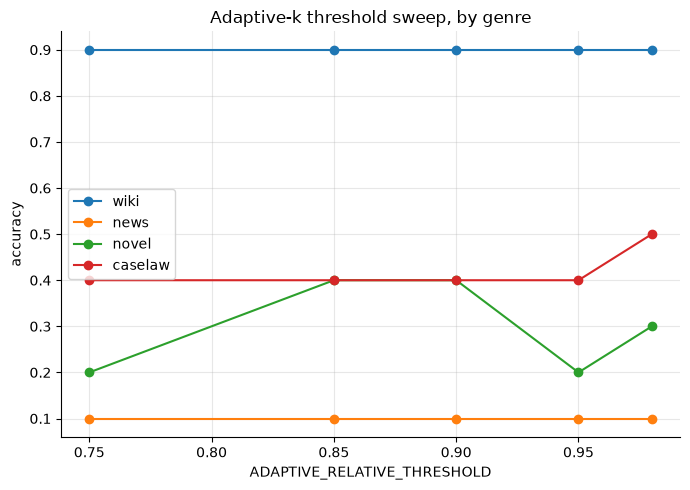

In [141]:
adaptive_sweep_df = pd.read_csv(ADAPTIVE_SWEEP_RESULTS_PATH, encoding="utf-8-sig") if os.path.exists(ADAPTIVE_SWEEP_RESULTS_PATH) else pd.DataFrame()

if adaptive_sweep_df.empty:
    print(f"No data yet in {ADAPTIVE_SWEEP_RESULTS_PATH} -- set ADAPTIVE_SWEEP_CONFIRM_SPEND = True above and run the sweep first.")
else:
    per_genre = adaptive_sweep_df.groupby(["threshold", "genre"])["correct"].mean().unstack("genre")
    per_genre = per_genre.reindex(columns=[g for g in GENRE_ORDER if g in per_genre.columns])
    per_genre["overall"] = adaptive_sweep_df.groupby("threshold")["correct"].mean()
    print(per_genre.round(3).to_string())

    best_caselaw_threshold = per_genre["caselaw"].idxmax() if "caselaw" in per_genre.columns else None
    print(f"\nbest caselaw threshold: {best_caselaw_threshold} "
          f"(caselaw {per_genre.loc[best_caselaw_threshold, 'caselaw']:.3f} vs current-default 0.85's "
          f"{per_genre.loc[0.85, 'caselaw'] if 0.85 in per_genre.index else float('nan'):.3f}, "
          f"per-genre-cap reference 0.450)")

    fig, ax = plt.subplots(figsize=(7, 5))
    for genre in [g for g in GENRE_ORDER if g in per_genre.columns]:
        ax.plot(per_genre.index, per_genre[genre], marker="o", label=genre, color=CONDITION_COLORS.get(genre))
    ax.set_xlabel("ADAPTIVE_RELATIVE_THRESHOLD")
    ax.set_ylabel("accuracy")
    ax.set_title("Adaptive-k threshold sweep, by genre")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 14. Compare all conditions

Loads `03`'s baselines + this notebook's conditions into one combined table; everything below reads from it.


In [142]:
# matplotlib/numpy/pandas/Path already imported at the top of the notebook.
# CONDITIONS_ORDER / CONDITION_COLORS / GENRE_ORDER / baseline_df are defined
# early now (right after GENRES) -- see the note there.
rehearsal_path = Path("results/qa_stage2_rehearsal_condition.csv")
rehearsal_df = pd.read_csv(rehearsal_path, encoding="utf-8-sig") if rehearsal_path.exists() else pd.DataFrame()
lookup_path = Path("results/qa_stage2_rehearsal_lookup_condition.csv")
lookup_df = pd.read_csv(lookup_path, encoding="utf-8-sig") if lookup_path.exists() else pd.DataFrame()
retrieval_path = Path("results/qa_stage2_rehearsal_lookup_retrieval_condition.csv")
retrieval_df = pd.read_csv(retrieval_path, encoding="utf-8-sig") if retrieval_path.exists() else pd.DataFrame()
adaptive_path = Path("results/qa_stage2_rehearsal_lookup_adaptive_condition.csv")
adaptive_df = pd.read_csv(adaptive_path, encoding="utf-8-sig") if adaptive_path.exists() else pd.DataFrame()

combined = pd.concat([baseline_df, rehearsal_df, lookup_df, retrieval_df, adaptive_df], ignore_index=True)
combined = combined[combined["condition"].isin(CONDITIONS_ORDER)]

accuracy = combined.pivot_table(index="genre", columns="condition", values="correct", aggfunc="mean")
accuracy = accuracy.reindex(GENRE_ORDER)[[c for c in CONDITIONS_ORDER if c in accuracy.columns]]
n = combined.pivot_table(index="genre", columns="condition", values="correct", aggfunc="count")
n = n.reindex(GENRE_ORDER)[[c for c in CONDITIONS_ORDER if c in n.columns]]
print("accuracy:")
print(accuracy)
print("\nn:")
print(n)

if not lookup_df.empty:
    print("\nlookup triggered rate by genre (base lookup condition):")
    print(lookup_df.groupby("genre")["lookup_used"].mean())
if not retrieval_df.empty:
    print("\nlookup triggered rate by genre (retrieval-augmented condition):")
    print(retrieval_df.groupby("genre")["lookup_used"].mean())

accuracy:
condition  closed_book  full_context  chunked_sequential  \
genre                                                      
wiki          0.280000      0.810000            0.190000   
news          0.040000      0.395000            0.010000   
novel         0.025316      0.493671            0.063291   
caselaw       0.335000      0.360000            0.225000   

condition  chunked_sequential_rehearsal  full_context_rehearsal_lookup  \
genre                                                                    
wiki                           0.230000                       0.370000   
news                           0.010000                       0.105000   
novel                          0.050633                       0.202532   
caselaw                        0.185000                       0.250000   

condition  full_context_rehearsal_lookup_retrieval  \
genre                                                
wiki                                      0.620000   
news                  

## Accuracy by genre x condition

Key pairs: chunked_sequential vs +rehearsal (does B alone help?), full_context vs +lookup (does B+lookup close the gap?).


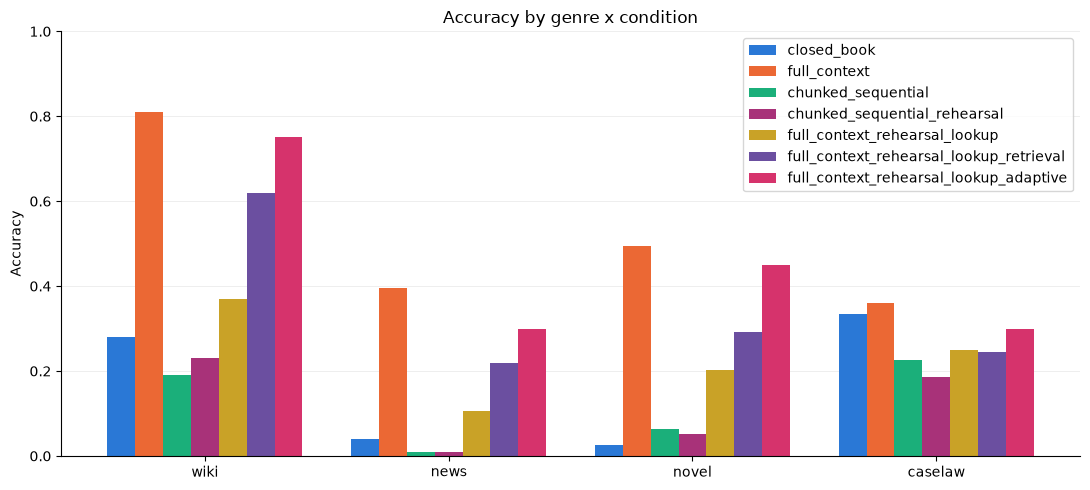

In [143]:
accuracy = combined.pivot_table(index="genre", columns="condition", values="correct", aggfunc="mean")
accuracy = accuracy.reindex(GENRE_ORDER)[[c for c in CONDITIONS_ORDER if c in accuracy.columns]]

x = range(len(accuracy))
bar_width = 0.8 / len(accuracy.columns)
fig, ax = plt.subplots(figsize=(11, 5))
for i, condition in enumerate(accuracy.columns):
    ax.bar([xi + i * bar_width for xi in x], accuracy[condition], width=bar_width,
           label=condition, color=CONDITION_COLORS[condition])
ax.set_xticks([xi + bar_width * (len(accuracy.columns) - 1) / 2 for xi in x])
ax.set_xticklabels(accuracy.index)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by genre x condition")
ax.set_ylim(0, 1)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)
ax.legend()
plt.tight_layout()
plt.show()

## Accuracy per token — accuracy / efficiency

Divides accuracy by token cost so cheap+accurate conditions stand out.


accuracy per 10,000 tokens, by genre x condition:
condition  full_context  chunked_sequential  chunked_sequential_rehearsal  full_context_rehearsal_lookup  full_context_rehearsal_lookup_retrieval  full_context_rehearsal_lookup_adaptive
genre                                                                                                                                                                                    
wiki              0.414               0.426                         1.317                          0.425                                    0.636                                   0.928
news              0.061               0.033                         0.054                          0.040                                    0.082                                   0.107
novel             0.061               0.247                         0.286                          0.065                                    0.093                                   0.145
caselaw           0.

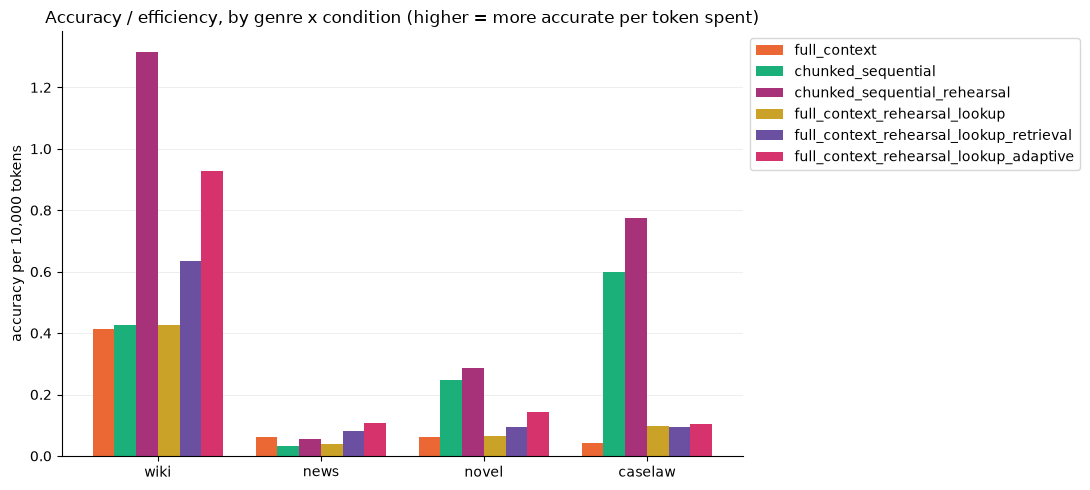

In [144]:
EFFICIENCY_CONDITIONS = [c for c in CONDITIONS_ORDER if c != "closed_book"]  # excluded: near-zero tokens makes its ratio a meaningless outlier, and it never reads the document anyway

tokens_by_genre_condition = combined.pivot_table(index="genre", columns="condition", values="total_tokens", aggfunc="mean")
tokens_by_genre_condition = tokens_by_genre_condition.reindex(GENRE_ORDER)[[c for c in EFFICIENCY_CONDITIONS if c in tokens_by_genre_condition.columns]]

# accuracy per 10,000 tokens -- raw accuracy/tokens is a tiny number (tokens are in the tens of thousands), scaled for readability
accuracy_for_efficiency = accuracy[[c for c in EFFICIENCY_CONDITIONS if c in accuracy.columns]]
accuracy_per_10k_tokens = accuracy_for_efficiency / tokens_by_genre_condition * 10_000
print("accuracy per 10,000 tokens, by genre x condition:")
print(accuracy_per_10k_tokens.round(3).to_string())

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(accuracy_per_10k_tokens))
bar_width = 0.8 / len(accuracy_per_10k_tokens.columns)
for i, condition in enumerate(accuracy_per_10k_tokens.columns):
    ax.bar([xi + i * bar_width for xi in x], accuracy_per_10k_tokens[condition], width=bar_width,
           label=condition, color=CONDITION_COLORS[condition])
ax.set_xticks([xi + bar_width * (len(accuracy_per_10k_tokens.columns) - 1) / 2 for xi in x])
ax.set_xticklabels(accuracy_per_10k_tokens.index)
ax.set_ylabel("accuracy per 10,000 tokens")
ax.set_title("Accuracy / efficiency, by genre x condition (higher = more accurate per token spent)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()


## Accuracy by evidence position in the document

chunked_sequential only sees the first 4 chunks — accuracy should fall off with evidence depth; B's memory should soften that.


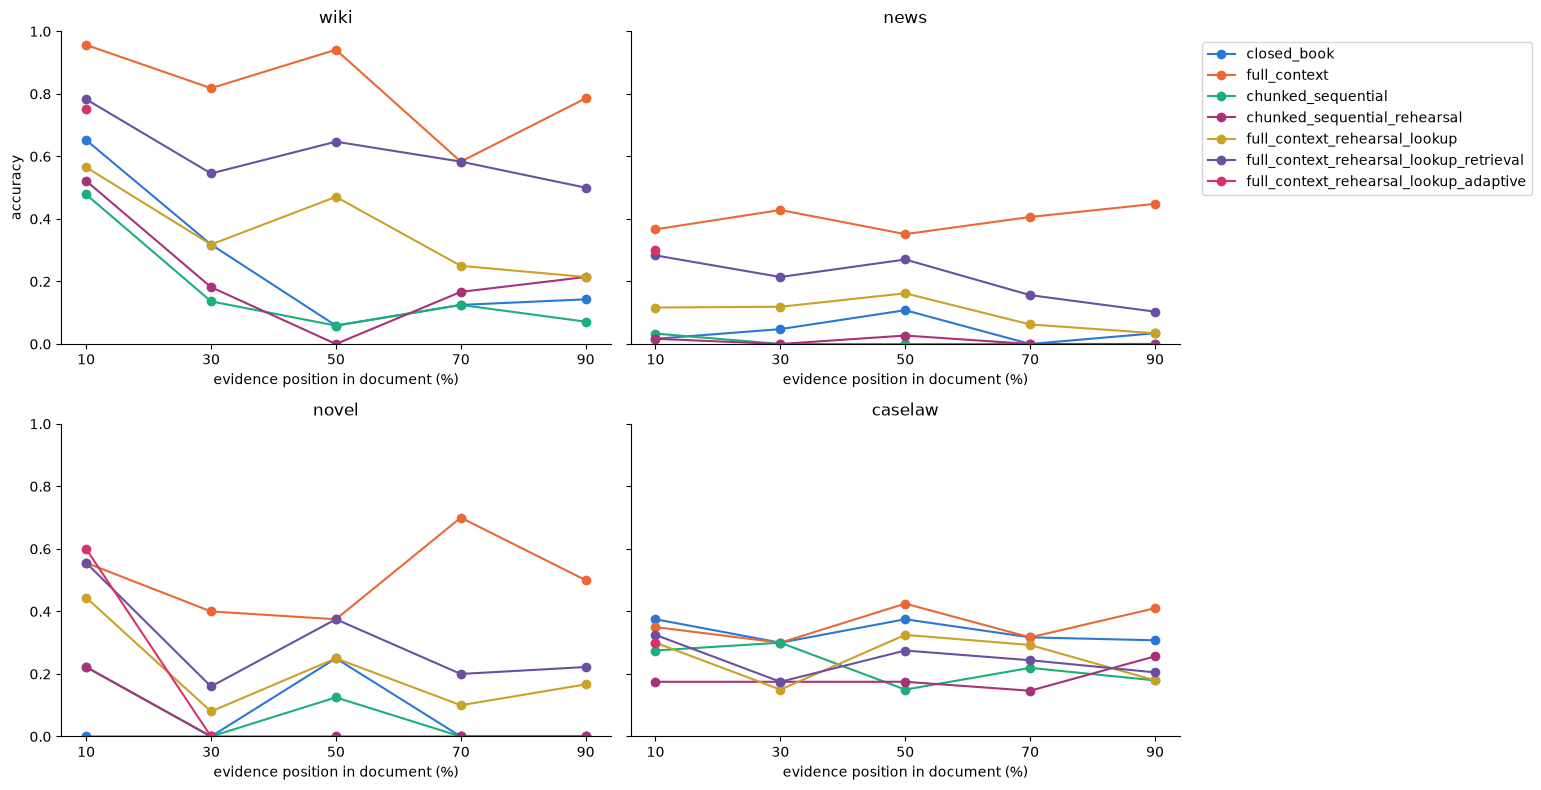

In [145]:
def evidence_fraction(genre: str, question_id) -> float | None:
    qdf = questions[genre]
    if "evidence_char_pos" not in qdf.columns:
        return None
    row = qdf[qdf["question_id"].astype(str) == str(question_id)]
    if row.empty or pd.isna(row["evidence_char_pos"].iloc[0]):
        return None
    return row["evidence_char_pos"].iloc[0] / len(corpora[genre])

combined["position_frac"] = combined.apply(
    lambda r: evidence_fraction(r["genre"], r["question_id"]), axis=1
)

bin_edges = [0, 0.2, 0.4, 0.6, 0.8, 1.0001]
bin_labels = [10, 30, 50, 70, 90]
combined["position_bin"] = pd.cut(
    combined["position_frac"], bins=bin_edges, labels=bin_labels, include_lowest=True
)

n_genres = len(GENRE_ORDER)
ncols = 2
nrows = -(-n_genres // ncols)  # ceil
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharey=True)
axes = axes.flatten()
for ax, genre in zip(axes, GENRE_ORDER):
    sub = combined[combined["genre"] == genre]
    for condition in CONDITIONS_ORDER:
        cond_sub = sub[sub["condition"] == condition]
        if cond_sub.empty:
            continue
        acc_by_bin = cond_sub.groupby("position_bin", observed=True)["correct"].mean().reindex(bin_labels)
        ax.plot(bin_labels, acc_by_bin.values, marker="o", label=condition, color=CONDITION_COLORS[condition])
    ax.set_title(genre)
    ax.set_xlabel("evidence position in document (%)")
    ax.set_xticks(bin_labels)
    ax.set_ylim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes[n_genres:]:
    ax.set_visible(False)
axes[0].set_ylabel("accuracy")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(1.0, 0.95))
plt.tight_layout()
plt.show()

## Efficiency by genre, across methods

Same read as `03`'s efficiency table, extended to the new conditions.


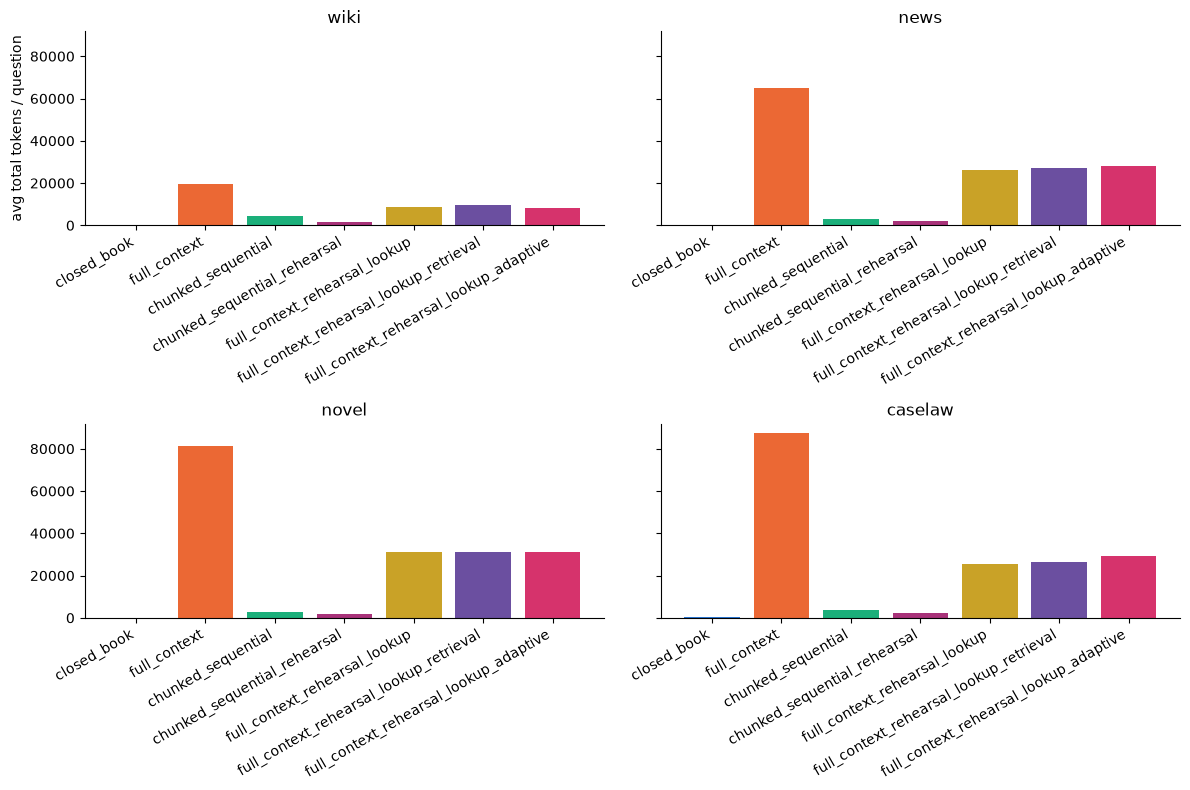

In [146]:
efficiency = combined.groupby(["genre", "condition"]).agg(
    avg_tokens=("total_tokens", "mean"),
    avg_api_calls=("api_calls", "mean"),
    avg_seconds=("elapsed_seconds", "mean"),
).reset_index()

n_genres = len(GENRE_ORDER)
ncols = 2
nrows = -(-n_genres // ncols)  # ceil
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharey=True)
axes = axes.flatten()
for ax, genre in zip(axes, GENRE_ORDER):
    sub = efficiency[efficiency["genre"] == genre].set_index("condition").reindex(
        [c for c in CONDITIONS_ORDER if c in efficiency["condition"].unique()]
    )
    ax.bar(range(len(sub)), sub["avg_tokens"], color=[CONDITION_COLORS[c] for c in sub.index])
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub.index, rotation=30, ha="right")
    ax.set_title(genre)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes[n_genres:]:
    ax.set_visible(False)
axes[0].set_ylabel("avg total tokens / question")
plt.tight_layout()
plt.show()

## Efficiency by method, across genres

Same numbers as the prior plot, transposed — spot cost outliers by genre.


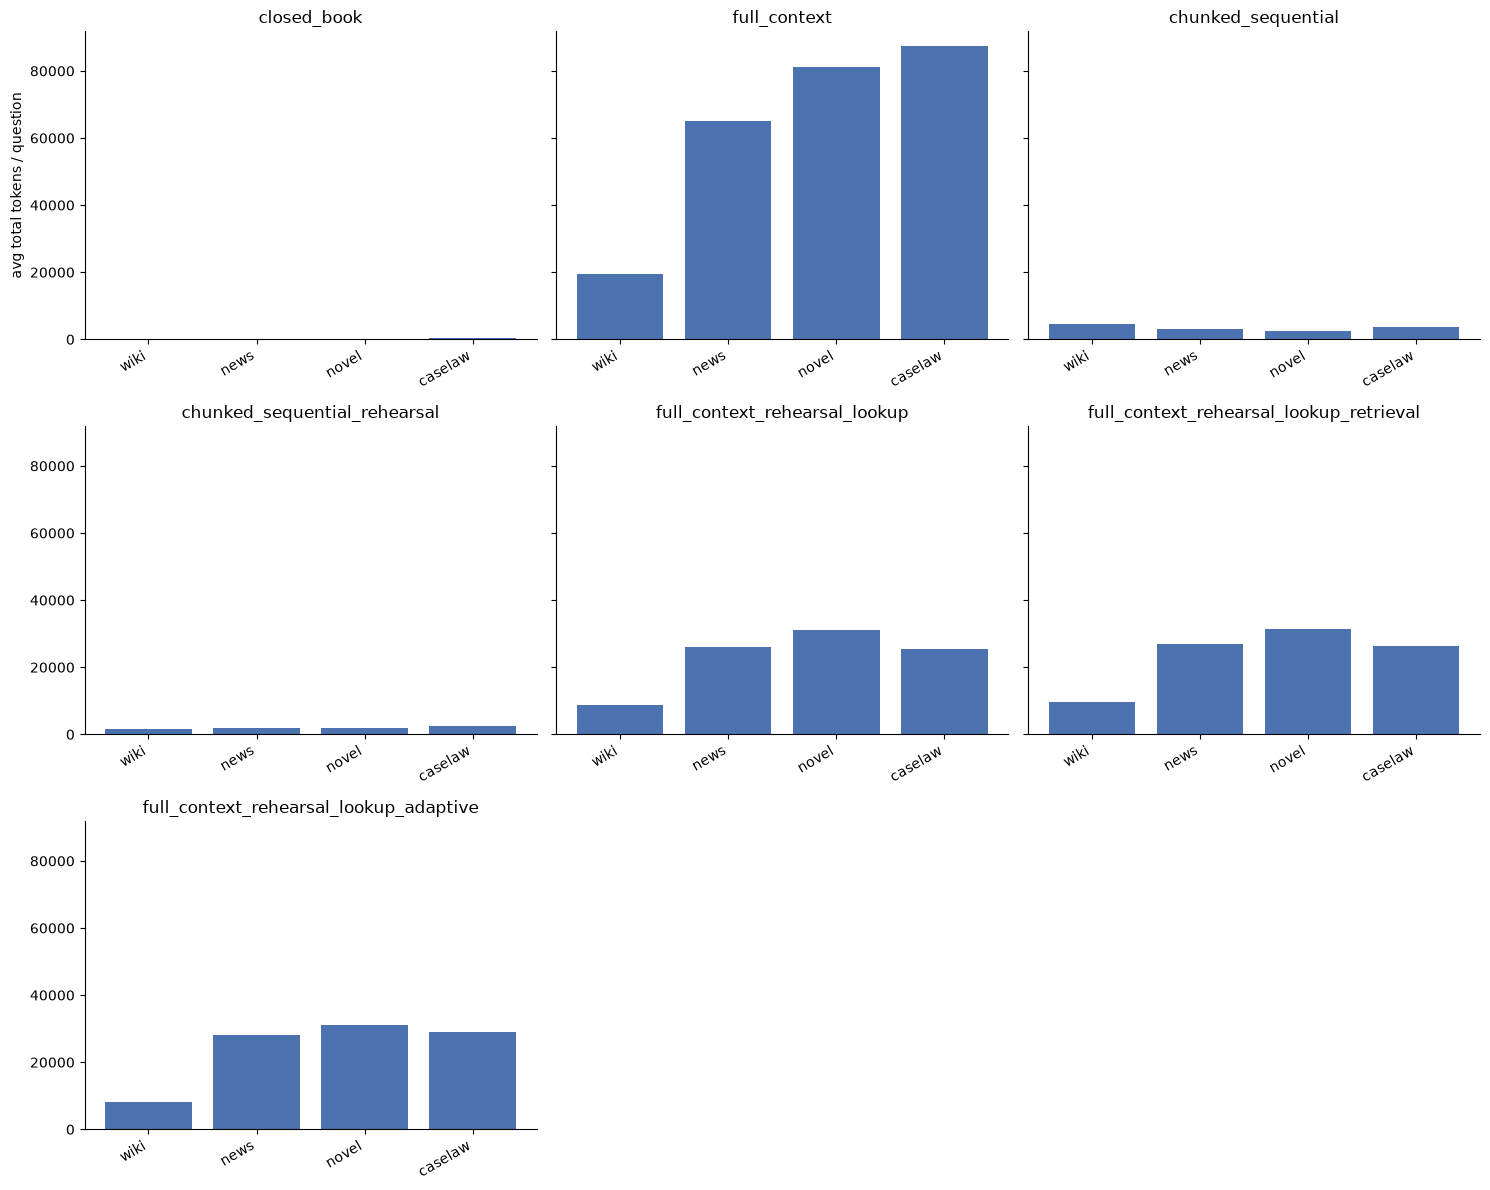

In [147]:
conditions_present = [c for c in CONDITIONS_ORDER if c in efficiency["condition"].unique()]

n_cond = len(conditions_present)
ncols = min(3, n_cond)  # up to 3 per row
nrows = -(-n_cond // ncols)  # ceil
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=True)
axes = axes.flatten() if n_cond > 1 else [axes]
for ax, condition in zip(axes, conditions_present):
    sub = efficiency[efficiency["condition"] == condition].set_index("genre").reindex(GENRE_ORDER)
    ax.bar(range(len(sub)), sub["avg_tokens"], color="#4c72b0")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub.index, rotation=30, ha="right")
    ax.set_title(condition)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes[n_cond:]:
    ax.set_visible(False)
axes[0].set_ylabel("avg total tokens / question")
plt.tight_layout()
plt.show()

## Summary

**4 conditions**, all testing B vs `03`'s baselines.

| # | condition | idea | status |
|---|---|---|---|
| 1 | `chunked_sequential_rehearsal` | B's gist, same 4-chunk budget as uncompressed control | full scale (579) |
| 2 | `full_context_rehearsal_lookup` | full gist map + raw-text lookup (ReadAgent-P) | full scale (579) |
| 3 | `full_context_rehearsal_lookup_retrieval` | + embedding-similarity targeting | full scale (579) |
| 4 | `full_context_rehearsal_lookup_adaptive` | fixed top-K → similarity-distribution-driven selection | may be pilot-scale |

**Headline**: none beats `full_context` at full scale; condition 4 is closest and cheapest (50-70% fewer tokens). Condition 1 can't win by construction (kept as reference).

**Lookup bug found+fixed** (conditions 2/3): second call resent the full gist block, burying the raw-text addition — see §8-9.

**Per-genre cap tried, worked, retired** for condition 4's generalizable adaptive-k (see §13).

**`07b`'s checkpoint quality is a shared ceiling** — none of these conditions retrain the compressor.

**Caselaw caveat**: eval corpus still has the `<HOLDING>` artifact.

**Sample sizes vary** — check `n` in §14 before treating any genre as settled.

**Scope**: B (elaborative) only — A, A→B, lookup+A not built.
